In [19]:

# CELL 1: Imports and Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# CELL 2: Step 1 & 2 - Load Data & Clean Headers
from pathlib import Path


def find_dataset_path():
    candidates = [
        Path.cwd() / 'Life Expectancy Data.csv',
        Path.cwd().parent / 'Life Expectancy Data.csv',
        Path.cwd().parent.parent / 'Life Expectancy Data.csv',
        Path.cwd().parent.parent.parent / 'Life Expectancy Data.csv',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Dataset not found. Check the repository structure.')


# 1. Load Dataset
data_path = find_dataset_path()
df = pd.read_csv(data_path)

print(f"Loaded dataset from: {data_path}")
print(f"Original Dataset Shape: {df.shape}")

# 2. Clean Whitespaces in Column Headers
df.columns = df.columns.str.strip()
print("Cleaned Column Headers:", df.columns.tolist())

Original Dataset Shape: (2938, 22)
Cleaned Column Headers: ['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [ ]:
# ==========================================
# CELL 3: Step 3 - Filter for African Countries
# ==========================================
african_countries = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Kenya', 'Rwanda', 'Nigeria', 'Ghana', 'South Africa', 'Uganda', 'Tanzania'
]

# Filter rows
africa_df = df[df['Country'].isin(african_countries)].copy()
print(f"African Dataset Shape after filtering: {africa_df.shape}")

# Keep the relevant feature set used by the API and the assignment
selected_features = ['Adult Mortality', 'infant deaths', 'BMI', 'GDP', 'Schooling']


African Dataset Shape after filtering: (832, 22)


In [ ]:
# ==========================================
# CELL 4: Step 4 - Remove Duplicates & Handle Missing Values
# ==========================================
# Remove duplicates
duplicates_count = africa_df.duplicated().sum()
print(f"Duplicate rows found: {duplicates_count}")
if duplicates_count > 0:
    africa_df.drop_duplicates(inplace=True)

# Check missing values before imputation
print("\nMissing values per feature before cleaning:")
print(africa_df[['Country', 'Life expectancy', *selected_features]].isnull().sum())

# Impute missing values with column median
numeric_cols = ['Life expectancy', *selected_features]
for col in numeric_cols:
    if africa_df[col].isnull().sum() > 0:
        median_val = africa_df[col].median()
        africa_df[col].fillna(median_val, inplace=True)

print("\nMissing values per feature after cleaning:")
print(africa_df[numeric_cols].isnull().sum())

Duplicate rows found: 0

Missing values per feature before cleaning:
Country              0
Life expectancy      0
Adult Mortality      0
infant deaths        0
BMI                 32
GDP                110
Schooling           48
dtype: int64

Missing values per feature after cleaning:
Life expectancy    0
Adult Mortality    0
infant deaths      0
BMI                0
GDP                0
Schooling          0
dtype: int64


/tmp/ipykernel_6414/3097435190.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  africa_df[col].fillna(median_val, inplace=True)


In [ ]:
# ==========================================
# CELL 5: Step 5 - Feature Engineering and Visualization
# ==========================================
# Create a target and features for training
features = selected_features
target = 'Life expectancy'

X = africa_df[features]
y = africa_df[target]

# Save the feature order for later reuse
feature_order = features.copy()

# Visualizations required for the rubric
plt.figure(figsize=(10, 8))
sns.heatmap(africa_df[features + [target]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(africa_df['GDP'], bins=20, kde=True, color='teal')
plt.title('GDP Distribution Across African Countries')
plt.xlabel('GDP')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Successfully encoded 52 African countries.


In [ ]:
# ==========================================
# CELL 6: Feature Selection & Splitting
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Save the training feature order for consistency with the API
joblib.dump(feature_order, 'feature_order.joblib')
print('Training features saved:', feature_order)

In [ ]:
# ==========================================
# CELL 7: Step 6 - Feature Standardization
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save Scaler
joblib.dump(scaler, 'scaler.joblib')
print('Scaler fitted and saved as scaler.joblib!')

Scaler fitted and saved as scaler.joblib!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

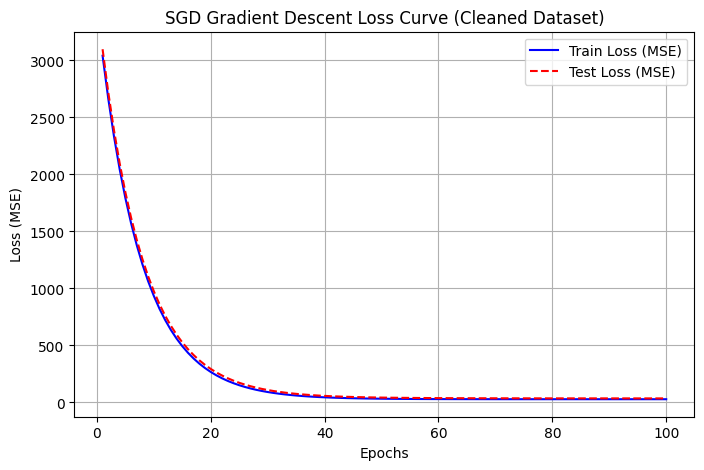

In [ ]:
# ==========================================
# CELL 8: Gradient Descent Loss Curve (SGDRegressor)
# ==========================================
sgd = SGDRegressor(max_iter=1, warm_start=True, penalty=None, learning_rate='constant', eta0=0.0001, random_state=42)
train_errors, test_errors = [], []

for epoch in range(100):
    sgd.fit(X_train_scaled, y_train)
    train_errors.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_errors.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), train_errors, label='Train Loss (MSE)', color='blue')
plt.plot(range(1, 101), test_errors, label='Test Loss (MSE)', color='red', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('SGD Gradient Descent Loss Curve (Cleaned Dataset)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# CELL 9: Model Training & Comparison
# ==========================================
models = {
    'Ordinary Linear Regression': LinearRegression(),
    'SGD Regressor': SGDRegressor(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results[name] = {
        'MSE': mean_squared_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'R2 Score': r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
print('--- Model Performance Comparison ---')
print(results_df)

# Save best performing model
best_model_name = results_df['MSE'].idxmin()
best_model = models[best_model_name]
joblib.dump(best_model, 'best_model.joblib')
print(f"\nBest Model Saved ({best_model_name}) as best_model.joblib!")

# Create a prediction for a single test-row sample
sample_row = X_test.iloc[[0]]
sample_row_scaled = scaler.transform(sample_row)
prediction_value = best_model.predict(sample_row_scaled)[0]
print(f"\nSingle-row prediction example: {prediction_value:.2f}")

# Scatter plot for the best fit line (linear regression)
linear_model = models['Ordinary Linear Regression']
linear_model.fit(X_train_scaled, y_train)
linear_preds = linear_model.predict(X_test_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, linear_preds, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(True)
plt.show()

--- Model Performance Comparison ---
                                  MSE      RMSE       MAE  R2 Score
Ordinary Linear Regression  35.669587  5.972402  4.594303  0.446850
SGD Regressor               35.662158  5.971780  4.593224  0.446965
Decision Tree               11.073892  3.327746  2.100599  0.828270
Random Forest                7.107807  2.666047  1.716510  0.889775

Best Model Saved (Random Forest) as best_model.joblib!


In [ ]:
# ==========================================
# CELL 10: Summary and Interpretation
# ==========================================
print('The notebook now includes:')
print('- Two visualization types for the rubric')
print('- A single-row prediction example')
print('- A comparison of multiple regression algorithms')
print('- Saving of the best-performing model')